In [1]:
from google.colab import files
uploaded = files.upload()

Saving supermarket.csv to supermarket.csv


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Customer Name  9994 non-null   object 
 2   Category       9994 non-null   object 
 3   Sub Category   9994 non-null   object 
 4   City           9994 non-null   object 
 5   Order Date     9994 non-null   object 
 6   Region         9994 non-null   object 
 7   Sales          9994 non-null   int64  
 8   Discount       9994 non-null   float64
 9   Profit         9994 non-null   float64
 10  State          9994 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 859.0+ KB


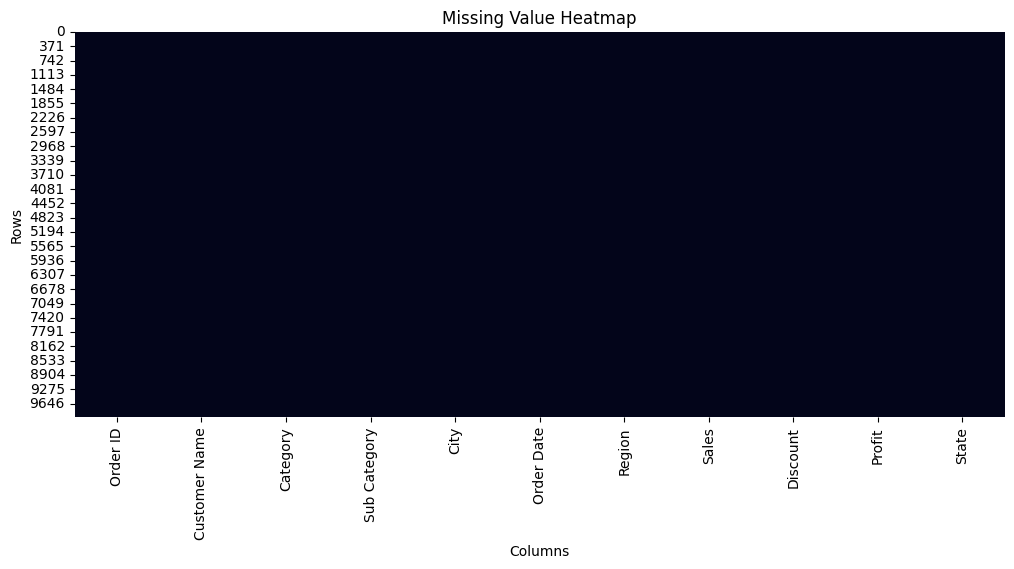

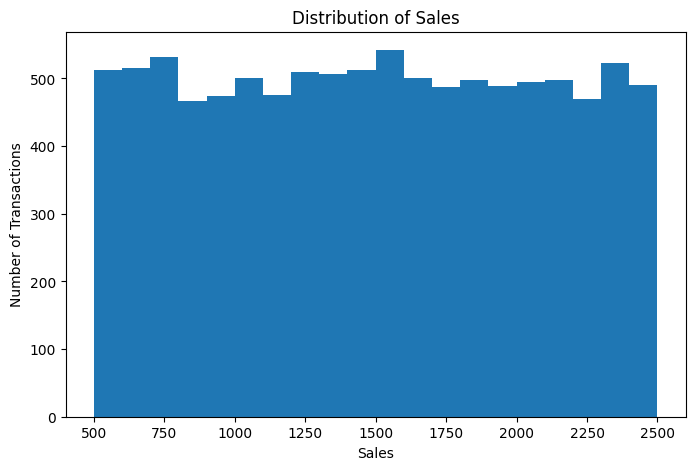

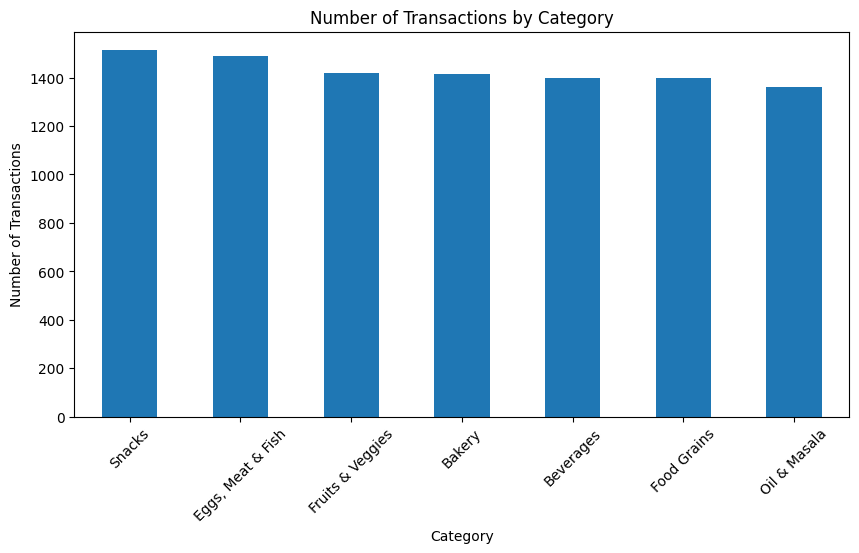

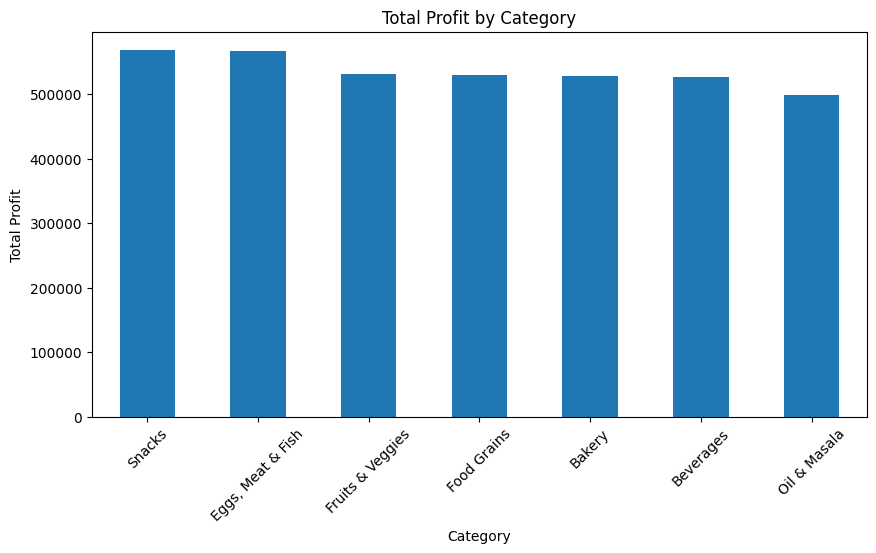

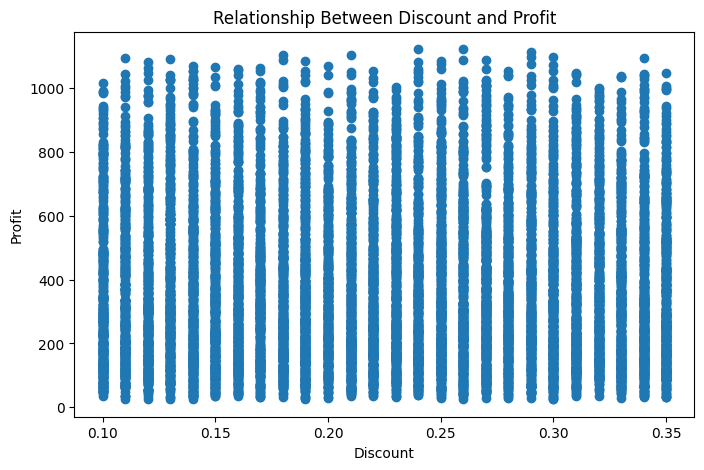

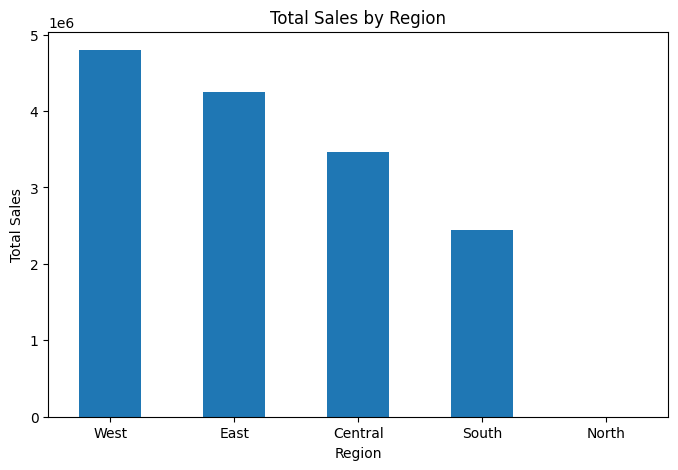

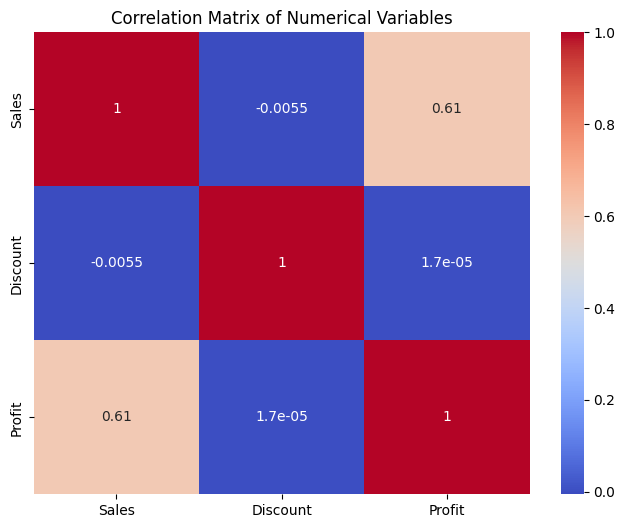

In [4]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 2. LOAD THE DATASET
# ============================================================

# Read the CSV file and store it in a DataFrame called df
df = pd.read_csv('supermarket.csv')

# Display the first 5 rows of the dataset
df.head()


# ============================================================
# 3. STRUCTURAL OVERVIEW OF THE DATASET
# ============================================================

# Check the number of rows and columns
df.shape

# Display the names of all columns
df.columns

# Check the data type of each column
df.dtypes

# Display detailed information about the dataset
# This includes column names, non-null values, data types and memory usage
df.info()

# Calculate memory usage of the DataFrame in MB
df.memory_usage(deep=True).sum() / (1024**2)

# Display the first 10 rows
df.head(10)

# Display the last 5 rows
df.tail()


# ============================================================
# 4. MISSING VALUE ANALYSIS
# ============================================================

# Count the number of missing values in each column
df.isnull().sum()

# Calculate the percentage of missing values in each column
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

# Create a summary table containing both
# missing-value count and missing-value percentage
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_summary


# ============================================================
# 5. VISUALIZE MISSING VALUES
# ============================================================

# Create a heatmap to visually identify missing values
# True = missing value, False = value is present
plt.figure(figsize=(12, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Value Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()


# ============================================================
# 6. NUMERICAL SUMMARY STATISTICS
# ============================================================

# Display basic statistical information for numerical columns
# Includes count, mean, standard deviation, minimum,
# quartiles and maximum
df.describe()

# Create a custom summary containing the statistics
# specifically required for the EDA
summary = pd.DataFrame({
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Std Dev': df.std(numeric_only=True),
    'Q1': df.quantile(0.25, numeric_only=True),
    'Q3': df.quantile(0.75, numeric_only=True)
})

summary


# ============================================================
# 7. CATEGORICAL VARIABLE ANALYSIS
# ============================================================

# Identify columns containing categorical/text data
df.select_dtypes(include='object').columns

# Count the frequency of each sub-category
df['Sub Category'].value_counts()

# Count the frequency of each main product category
df['Category'].value_counts()

# Count the frequency of each region
df['Region'].value_counts()


# ============================================================
# 8. VISUALIZATION 1 — DISTRIBUTION OF SALES
# ============================================================

# A histogram shows how Sales values are distributed
plt.figure(figsize=(8, 5))

plt.hist(df['Sales'], bins=20)

plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Number of Transactions')

plt.show()


# ============================================================
# 9. VISUALIZATION 2 — TRANSACTIONS BY CATEGORY
# ============================================================

# Count the number of transactions in each category
# and display them as a bar chart
plt.figure(figsize=(10, 5))

df['Category'].value_counts().plot(kind='bar')

plt.title('Number of Transactions by Category')
plt.xlabel('Category')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)

plt.show()


# ============================================================
# 10. VISUALIZATION 3 — TOTAL PROFIT BY CATEGORY
# ============================================================

# Group the data by Category and calculate
# the total profit generated by each category
profit_by_category = (
    df.groupby('Category')['Profit']
      .sum()
      .sort_values(ascending=False)
)

# Display the calculated profit values
profit_by_category

# Plot total profit for each category
plt.figure(figsize=(10, 5))

profit_by_category.plot(kind='bar')

plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)

plt.show()


# ============================================================
# 11. VISUALIZATION 4 — DISCOUNT VS PROFIT
# ============================================================

# A scatter plot is used to examine the relationship
# between Discount and Profit
plt.figure(figsize=(8, 5))

plt.scatter(df['Discount'], df['Profit'])

plt.title('Relationship Between Discount and Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.show()

# Calculate the correlation between Discount and Profit
# A value close to 0 indicates little/no linear relationship
df['Discount'].corr(df['Profit'])


# ============================================================
# 12. VISUALIZATION 5 — TOTAL SALES BY REGION
# ============================================================

# Group the data by Region and calculate
# total sales for each region
sales_by_region = (
    df.groupby('Region')['Sales']
      .sum()
      .sort_values(ascending=False)
)

# Display total sales by region
sales_by_region

# Plot total sales for each region
plt.figure(figsize=(8, 5))

sales_by_region.plot(kind='bar')

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()


# ============================================================
# 13. VISUALIZATION 6 — CORRELATION HEATMAP
# ============================================================

# Calculate correlations between the numerical variables
# and display them as a heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[['Sales', 'Discount', 'Profit']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()


# ============================================================
# 14. FINAL FINDINGS
# ============================================================

# Main findings from the EDA:
#
# 1. Snacks has the highest number of transactions (1,514)
#    and also generates the highest total profit.
#
# 2. Transaction counts are fairly evenly distributed
#    across the seven main product categories.
#
# 3. Sales and Profit have a moderate positive correlation
#    of approximately 0.61.
#
# 4. Discount and Profit have almost no linear correlation,
#    with a correlation close to 0.
#
# 5. The West region has the highest total sales among
#    the regions in the dataset.